<a href="https://colab.research.google.com/github/adwoaadusei/lab-3/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


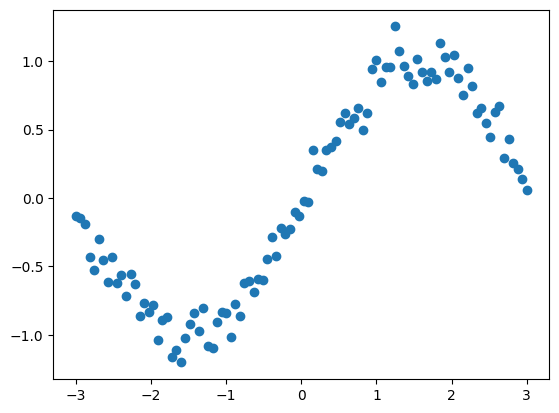

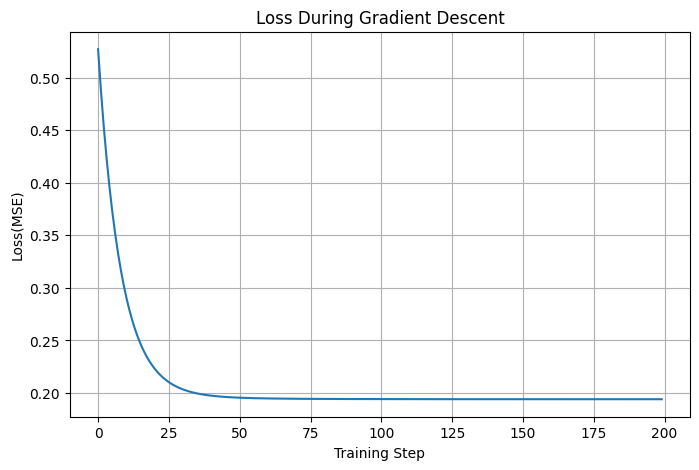

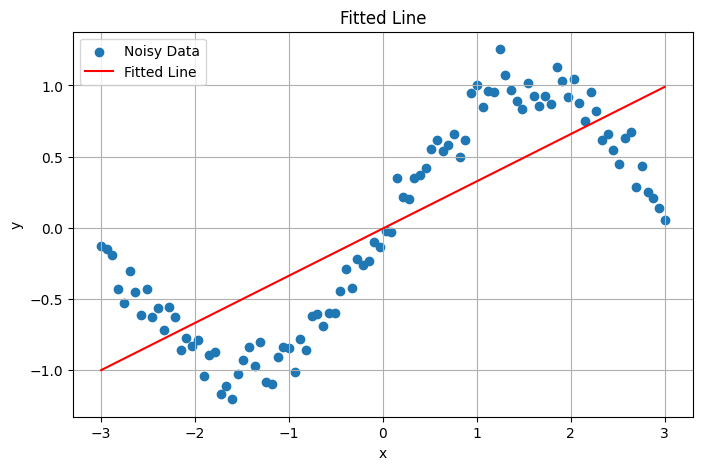

In [7]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

x = np.linspace(-3, 3, 100)
noise = np.random.normal(0, 0.1, 100)
y = np.sin(x) + noise
plt.plot(x, y, 'o')
#plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.normal(0, 0.1)
b = np.random.normal(0, 0.1)

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.
#   Record the loss at every step.

losses = []
for step in range(200):
  y_hat = w * x + b
  loss = np.mean((y_hat - y) ** 2)
  losses.append(loss)
  dw = np.mean(2 * (y_hat - y) * x)
  db = np.mean(2 * (y_hat - y))
  lr = 0.01
  w -= lr * dw
  b -= lr * db

  # TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss(MSE)")
plt.title("Loss During Gradient Descent")
plt.grid(True)

plt.figure(figsize=(8,5))
plt.scatter(x,y,label="Noisy Data")
plt.plot(x,y_hat,color="red",label="Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Single Neuron Fit")
plt.legend()
plt.grid(True)
plt.show()


1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?
 Yes it meatches the code.
 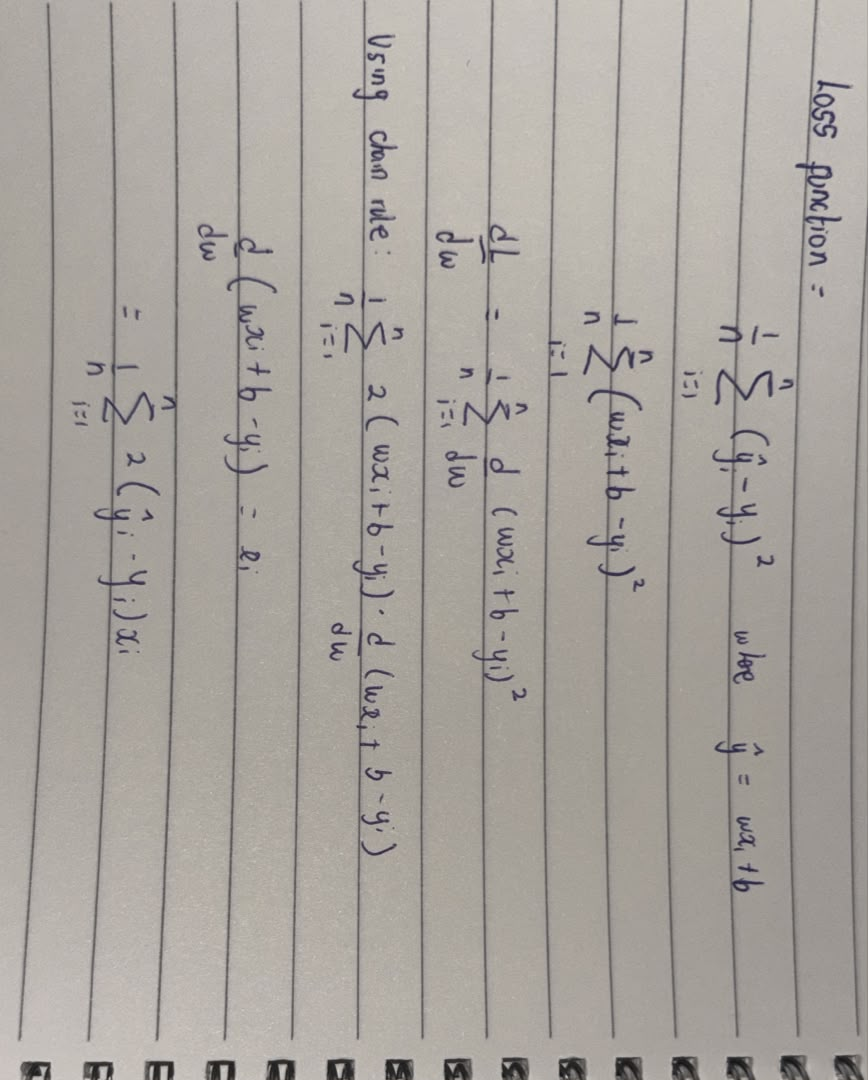

2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?

The neuron always uses y = wx + b which is a straight line. A sine curve function is a curve and a straight line can never become a curve. Eventually, the model will stop improving because it has reached the best straightline approximation of the data. Therefore it is underfitting.

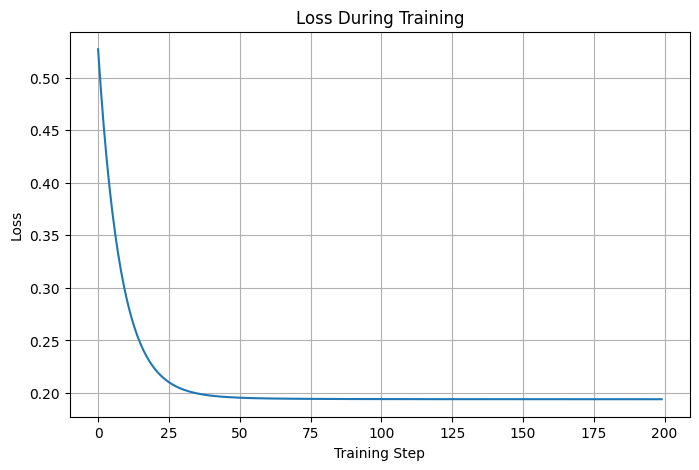

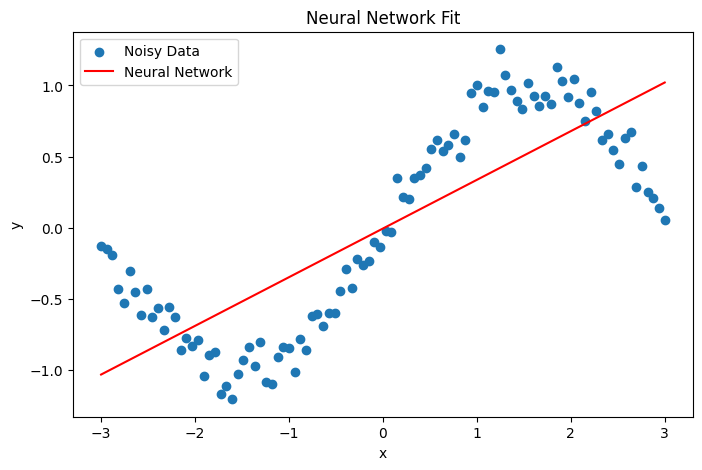

In [21]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

w1 = np.random.randn(1,8) * 0.5
b1 = np.random.randn(8) * 0.5
w2 = np.random.randn(8,1) * 0.5
b2 = np.random.randn(1) * 0.5

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)
x = x.reshape(-1,1)
y = y.reshape(-1,1)


# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)


# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss
lr = 0.001
loss_list = []
for step in range(3000):
  z1 = x @ w1 + b1
  h = z1
  y_hat = h @ w2 + b2
  loss = np.mean((y_hat - y) ** 2)
  loss_list.append(loss)

  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh = d_yhat @ w2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x.T @ dz1
  db1 = dz1.sum(axis=0)

  w1 -= lr * dW1
  b1 -= lr * db1
  w2 -= lr * dW2
  b2 -= lr * db2

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Loss During Training")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Noisy Data")
plt.plot(x, y_hat, color="red", label="Neural Network")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural Network Fit")
plt.legend()
plt.show()








1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer.

Since a linearlayer is y = wx+b. So stacking linear layers without a non-linear activation is mathemathically equivalent to s ingle linear layer.

 2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of h against x.)

 The 8 hidden neurons each learned a different nonlinear feature of the input after the tanh activation. These causes their outputs to form a richer representation of the data. This allows the output neuron to combine these feature and approximate the curved shape of the sine function. Without these hidden neurons, the network would only be able to produce a striaght line.

 3. This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?

 Backpropagation is the process of applying the chain rule to compute the gradients of the loss wrt to every parameter in the neural network so the wieghts and biases can be updated using gradient descent.

/tmp/ipykernel_3359/1994142142.py:22: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_3359/1994142142.py:28: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ w2.T
/tmp/ipykernel_3359/1994142142.py:29: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


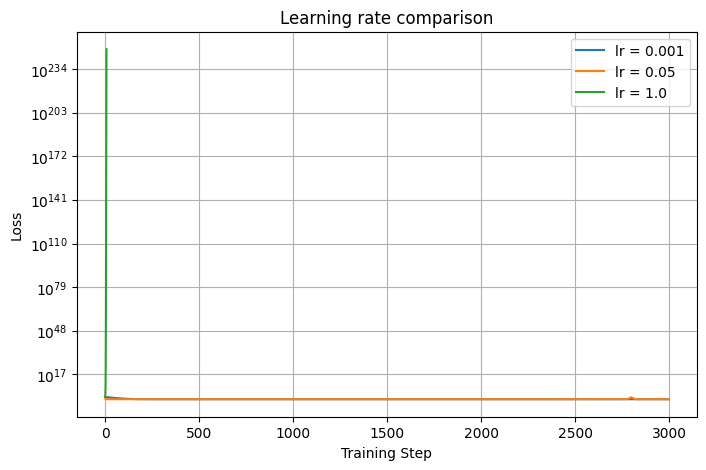

In [35]:

# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend

def train_toy(lr,steps=3000):
  np.random.seed(42)

  w1 = np.random.randn(1,8) * 0.5
  b1 = np.random.randn(8) * 0.5
  w2 = np.random.randn(8,1) * 0.5
  b2 = np.random.randn(1) * 0.5

  losses =[]
  for step in range(steps):
    z1 = x @ w1 + b1
    h = z1
    y_hat = h @ w2 + b2
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ w2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    w1 -= lr * dW1
    b1 -= lr * db1
    w2 -= lr * dW2
    b2 -= lr * db2

  return losses

loss_1 = train_toy(0.001)
loss_2 = train_toy(0.05)
loss_3 = train_toy(1.0)

plt.figure(figsize=(8,5))

plt.plot(loss_1, label="lr = 0.001")
plt.plot(loss_2, label="lr = 0.05")
plt.plot(loss_3, label="lr = 1.0")

plt.yscale("log")

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Learning rate comparison")
plt.grid(True)
plt.legend()

plt.show()





Describe what each of the three curves shows. Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?



*   lr = 0.001. The loss decreases steadily but slowly because the parameter updates are small, resulting in stable but slow convergence
*   lr = 0.05. The loss increases ,much faster but remains stable making it the most effective
*   lr = 1.0 . The loss increases too quicly, overflows and eventually becomes name meaning this rate is too large for

Instead of moving closer to the minimum, the updates jump past it causing the loss to increase uncontrollably



